
# Image Segmentation for Scanned PDF Pages

This Jupyter Notebook demonstrates a program that processes scanned PDF pages exported as images. 
It divides each page into equally sized horizontal segments while attempting to avoid cutting through lines of text using computer vision techniques.

### Features:
1. Load scanned PDF pages exported as images.
2. Divide each page into multiple horizontal segments.
3. Use image processing techniques to find gaps between lines of text for better segmentation.
4. Save each segment as a new image.

Adjust the parameters in the `USER-DEFINABLE PARAMETERS` section to control the behavior of the script.


In [2]:
import os
import re
import cv2
import numpy as np
import math
from glob import glob
import matplotlib.pyplot as plt

# Set up the working directory and parameters
EXPORT_DIR = "../export"
os.makedirs(EXPORT_DIR, exist_ok=True)

# User-definable parameters
NUM_SEGMENTS = 5  # Divide each page into 5 equal-height segments
SEGMENT_HEIGHT = None  # If specified, overrides NUM_SEGMENTS.
MAX_LINE_ADJUST = 30
KERNEL_SIZE = (30, 10)  # Morphological kernel size

In [3]:
# Function to display an image
def display_image(title, image, cmap='gray'):
    plt.figure(figsize=(10, 10))
    plt.title(title)
    plt.imshow(image, cmap=cmap)
    plt.axis('off')
    plt.show()

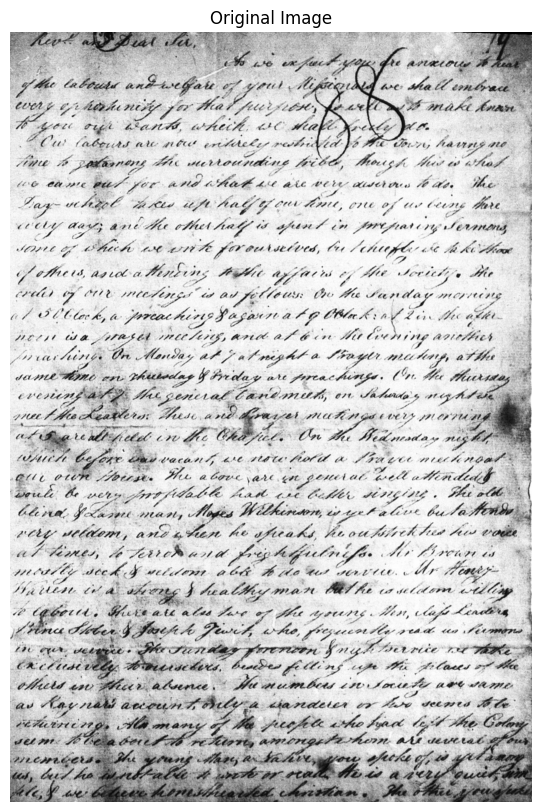

In [12]:
# Step 1: Load and display an image
image_path = "../export/sample_page.png"  # Replace with an actual file path
img = cv2.imread(image_path, cv2.IMREAD_COLOR)
if img is None:
    raise FileNotFoundError(f"Failed to read image: {image_path}")
display_image("Original Image", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

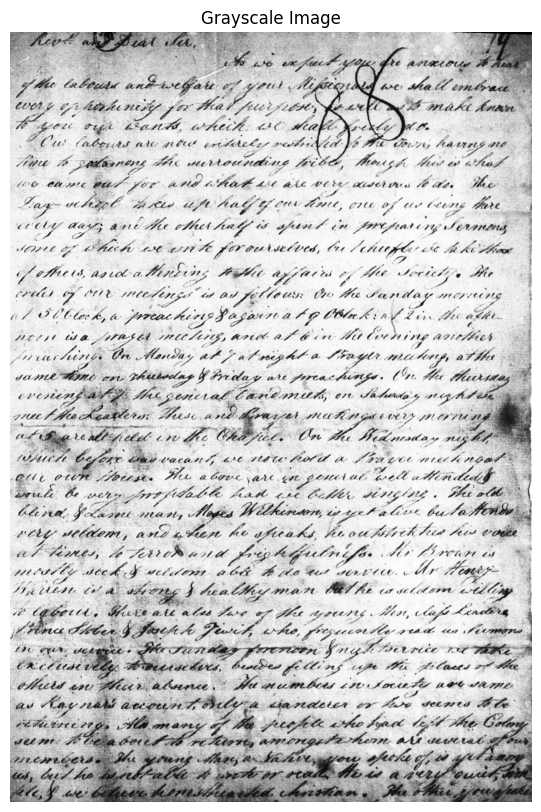

In [13]:
# Step 2: Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
display_image("Grayscale Image", gray)

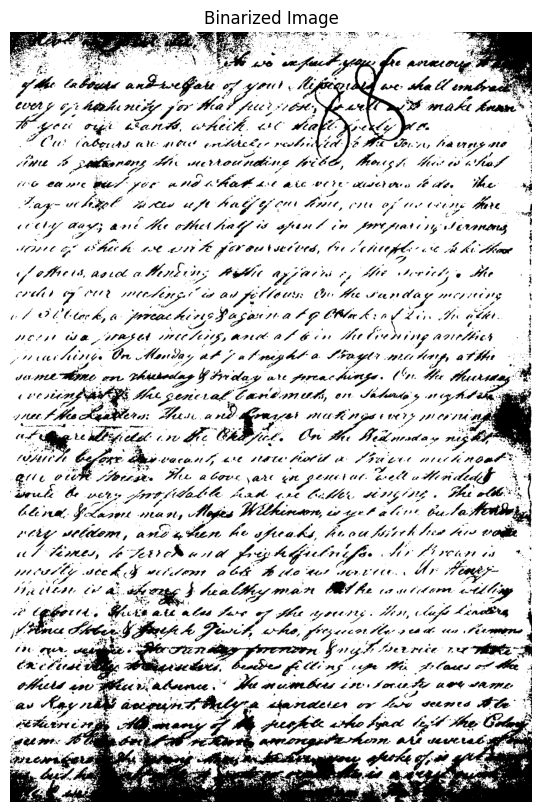

In [14]:
# Step 3: Binarize using Otsu's threshold
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
display_image("Binarized Image", thresh)


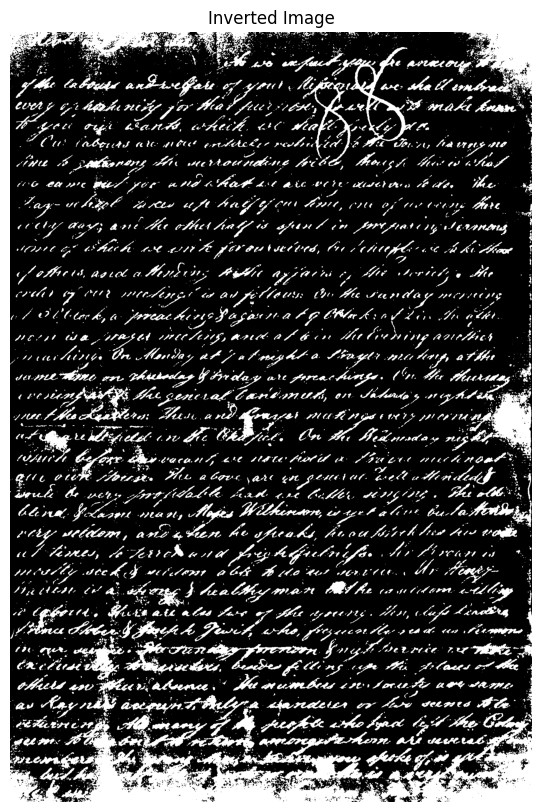

In [15]:
# Step 4: Invert the binary image
inverted = cv2.bitwise_not(thresh)
display_image("Inverted Image", inverted)


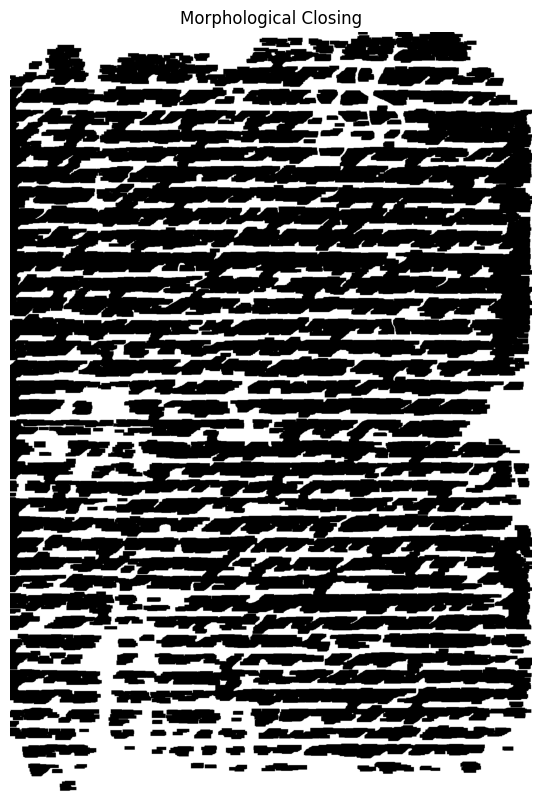

In [16]:
# Step 5: Morphological closing to enhance text regions
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, KERNEL_SIZE)
morph = cv2.morphologyEx(inverted, cv2.MORPH_CLOSE, kernel)
display_image("Morphological Closing", morph)


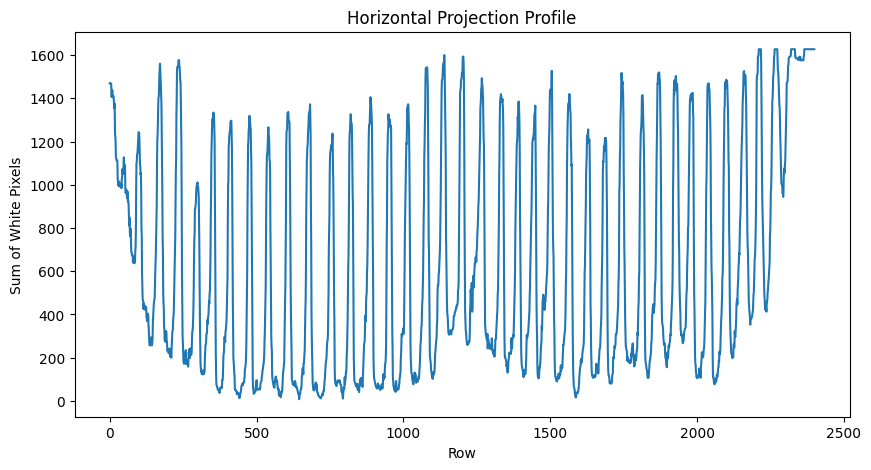

In [17]:
# Step 6: Compute horizontal projection profile
projection = np.sum(morph == 255, axis=1)
plt.figure(figsize=(10, 5))
plt.title("Horizontal Projection Profile")
plt.plot(projection)
plt.xlabel("Row")
plt.ylabel("Sum of White Pixels")
plt.show()

In [18]:
# Step 7: Determine segment boundaries and visualize
h, w = morph.shape
if SEGMENT_HEIGHT is not None:
    segment_height = SEGMENT_HEIGHT
    num_segments = math.ceil(h / segment_height)
else:
    num_segments = NUM_SEGMENTS
    segment_height = h / num_segments

cut_lines = []
for i in range(1, num_segments):
    line_pos = int(round(i * segment_height))
    best_line = line_pos
    best_val = projection[line_pos] if 0 <= line_pos < len(projection) else float('inf')

    start_line = max(0, line_pos - MAX_LINE_ADJUST)
    end_line = min(len(projection)-1, line_pos + MAX_LINE_ADJUST)

    for line_pos in range(start_line, end_line+1):
        val = projection[line_pos]
        if val < best_val:
            best_val = val
            best_line = line_pos

    cut_lines.append(best_line)

segment_boundaries = [0] + cut_lines + [h]

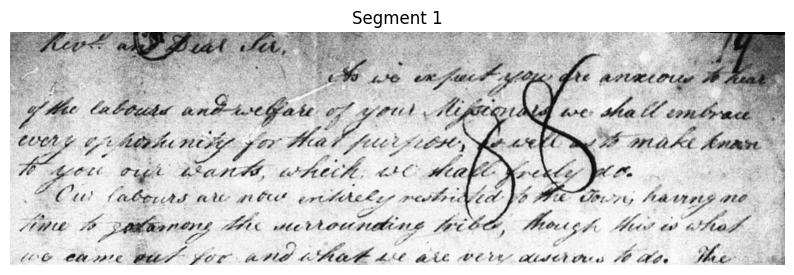

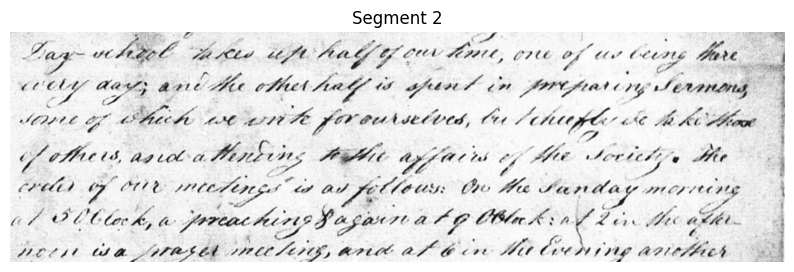

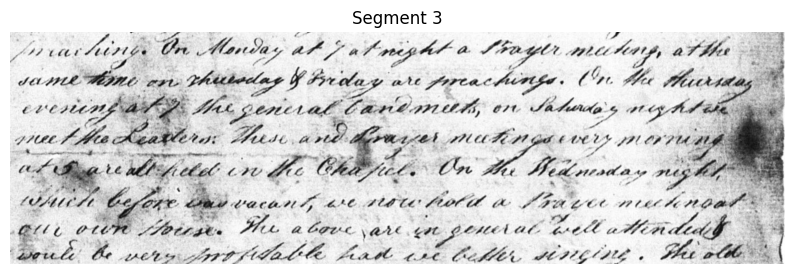

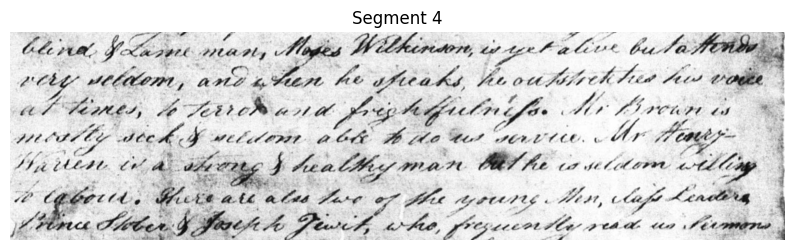

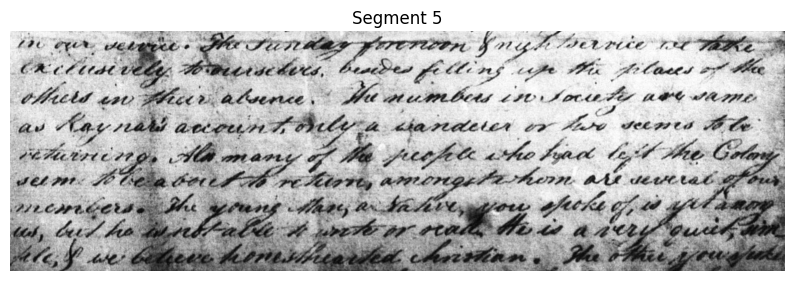

In [19]:
# Step 8: Save and display segments
for i in range(len(segment_boundaries)-1):
    top = segment_boundaries[i]
    bottom = segment_boundaries[i+1]
    segment_img = img[top:bottom, :]
    display_image(f"Segment {i+1}", cv2.cvtColor(segment_img, cv2.COLOR_BGR2RGB))
